# Lab 6

https://github.com/MTG/machine_learning_for_sound_and_music_25/blob/main/notebooks/08_01_transformers.ipynb

## Introduction

Modify the class notebook to train a transformer encoder model using the
MagnaTagATune (MTAT) dataset.
1. Adapt the provided implementation and train the model on MTAT
* You can reuse the data loading code from the previous assignment.
2. Evaluate the classification performance.
* Should include ROC-AUC, and PR-AUC scores.
3. Write a short report documenting your decisions and observations
* The report should be included in the notebook
* The notebook should be self-explanatory, and executable (i.e., it should contain the code to
install dependencies and setup the dataset). The assignment will be entirely evaluated on the
contents of the notebook.

## Imports

In [26]:
!pip install torchmetrics -q

In [27]:
import os
from google.colab import drive
from google.colab import files
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import librosa.display
import librosa
import glob
import random
import math

# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.autonotebook import tqdm

# Metrics
import torchmetrics
from sklearn.metrics import classification_report

In [28]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data Importing

### Auxiliar Functions

In [4]:
def visualize_spectrogram_npy(npy_path):
    """
    Loads an .npy file containing a log-scale Mel-spectrogram and visualizes it.

    Args:
        npy_path (str): Full path to the .npy file.
    """
    if not os.path.exists(npy_path):
        print(f"Error: File not found at path: {npy_path}")
        return

    # 1. Load the NumPy array
    try:
        log_mel_spectrogram = np.load(npy_path)
    except Exception as e:
        print(f"Error loading the .npy file: {e}")
        return

    # 2. Configure the figure
    plt.figure(figsize=(12, 4))

    # 3. Visualization using Librosa
    # We use Librosa.display.specshow for correct, labeled visualization,
    # assuming a sample rate of 16000 Hz.
    # It is crucial to specify y_axis='mel' and x_axis='time'.
    img = librosa.display.specshow(
        log_mel_spectrogram,
        sr=16000,           # Sample rate used during preprocessing
        x_axis='time',      # x-axis as time
        y_axis='mel',       # y-axis as Mel scale
        hop_length=512,     # Typical hop_length value (adjust if necessary)
        cmap='magma'        # Color scheme
    )

    # 4. Add labels and title
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f'Log-Mel Spectrogram for: {os.path.basename(npy_path)}')
    plt.tight_layout()
    plt.show()

### Importing

#### Importing Tags

In [5]:
if not os.path.isdir("/content/drive"):
  drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
try:
  df = pd.read_csv('/content/drive/MyDrive/SMC/MLSM/Lab3/annotations_final.csv', sep="\t", index_col=0)
except FileNotFoundError:
  uploaded = files.upload()
  df = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df = None

if df is not None:
    print(df.head())

         no voice  singer  duet  plucking  hard rock  world  bongos  \
clip_id                                                               
2               0       0     0         0          0      0       0   
6               0       0     0         0          0      0       0   
10              0       0     0         0          0      0       0   
11              0       0     0         0          0      0       0   
12              0       0     0         0          0      0       0   

         harpsichord  female singing  clasical  ...  rap  metal  hip hop  \
clip_id                                         ...                        
2                  0               0         0  ...    0      0        0   
6                  0               0         0  ...    0      0        0   
10                 0               0         0  ...    0      0        0   
11                 0               0         0  ...    0      0        0   
12                 0               0         0

In [8]:
df.shape

(25863, 189)

#### Importing Spectrograms

In [10]:
FINAL_ZIP_NAME = 'magna_tag_atune_spectrograms.zip'
DESTINATION_FOLDER = 'spectrograms'
BASE_PATH = '/content/drive/MyDrive/SMC/MLSM/Lab3' # Set this to the directory where your .001 files are located

with zipfile.ZipFile(os.path.join(BASE_PATH, FINAL_ZIP_NAME), 'r') as zf:
    zf.extractall(DESTINATION_FOLDER)

print(f"Success! All audio clips have been extracted to: {DESTINATION_FOLDER}")

Success! All audio clips have been extracted to: spectrograms


## Datasets

### Selecting Top 50 Tags

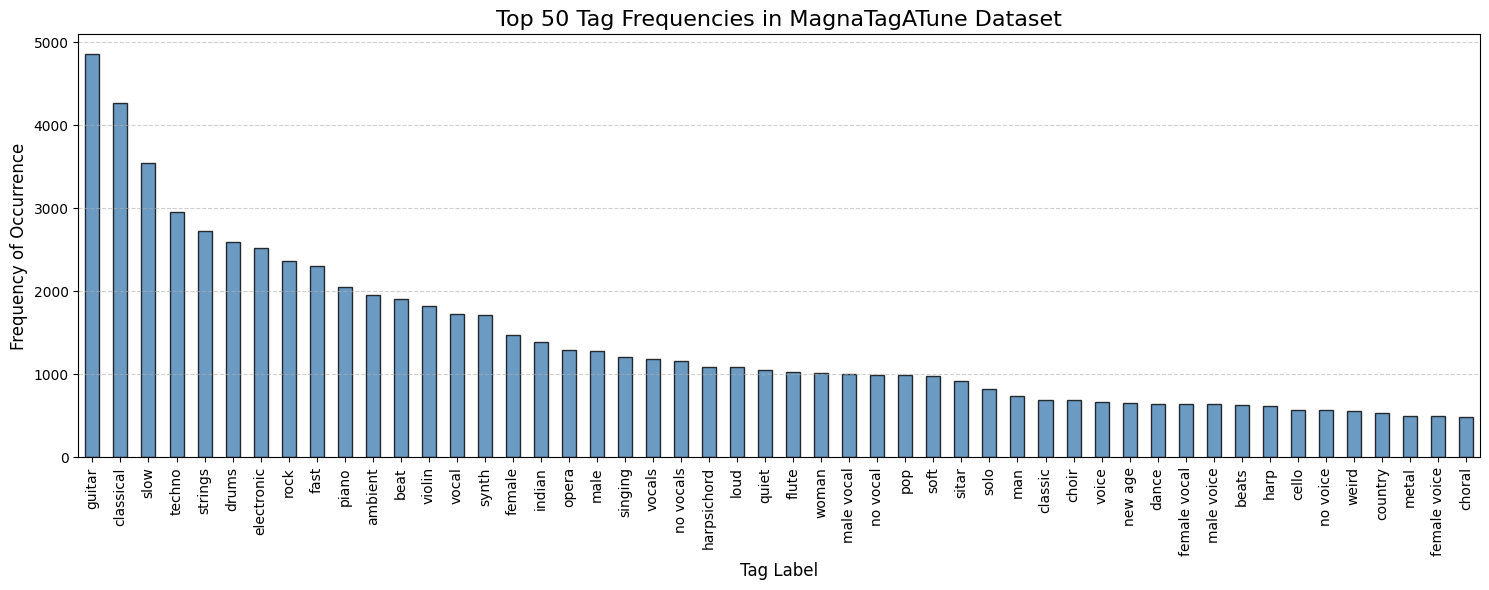

In [11]:
# 1. Calculate and select the top 50 tag counts
# df.iloc[:, :-1] selects all columns except the last one (assuming the last one is NOT a tag, e.g., clip_id)
tag_counts = df.iloc[:, :-1].sum().sort_values(ascending=False)
top_50_counts = tag_counts[:50]

# 2. Configure plot aesthetics
plt.figure(figsize=(15, 6)) # Better aspect ratio for bars

# 3. Create the bar plot directly
ax = top_50_counts.plot.bar(
    rot=90,             # Rotate x-labels for readability
    color='steelblue',  # Set a nice color
    edgecolor='k',      # Black border for clarity
    alpha=0.8
)

# 4. Set labels and title
ax.set_title('Top 50 Tag Frequencies in MagnaTagATune Dataset', fontsize=16)
ax.set_xlabel('Tag Label', fontsize=12)
ax.set_ylabel('Frequency of Occurrence', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6) # Add light grid lines

plt.tight_layout()
plt.show()

In [12]:
top_50_counts.index

Index(['guitar', 'classical', 'slow', 'techno', 'strings', 'drums',
       'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin',
       'vocal', 'synth', 'female', 'indian', 'opera', 'male', 'singing',
       'vocals', 'no vocals', 'harpsichord', 'loud', 'quiet', 'flute', 'woman',
       'male vocal', 'no vocal', 'pop', 'soft', 'sitar', 'solo', 'man',
       'classic', 'choir', 'voice', 'new age', 'dance', 'female vocal',
       'male voice', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
       'metal', 'female voice', 'choral'],
      dtype='object')

In [13]:
df_top50 = df[[c for c in top_50_counts.index] + ['mp3_path']]
df_top50.shape

(25863, 51)

In [14]:
tags = df.drop(columns=["mp3_path"]).columns.tolist()
df.apply(
    lambda row: row[tags][row[tags] == 1].index.tolist(),
    axis=1
)

,0
clip_id,
2,"[classical, strings, opera, violin]"
6,"[classical, violins, strings, classic, opera, ..."
10,"[classical, classic, opera]"
11,"[quiet, opera]"
12,"[classical, violins, strings, classic, violin]"
...,...
58899,"[guitar, classical guitar]"
58906,"[guitar, solo, strings, medieval, harp, slow, ..."
58907,"[classical, guitar, strings, slow]"


### Generate Datasets

In [15]:
class MagnaTagATuneDataset(Dataset):
    """
    PyTorch Dataset class for loading MagnaTagATune audio clips
    and their corresponding binary labels.
    """
    def __init__(self, data_dir, df, subset='train', sr=16000, duration=29.0, n_mels=64):
        """
        Initializes the dataset.

        Args:
            data_dir (str): Path to the base audio folder (e.g., 'dataset/').
            annotations_file (str): Path to the pre-processed CSV/TSV annotations file.
            sr (int): Sampling rate (MagnaTagATune uses 16000 Hz).
            duration (float): Clip duration in seconds (29.0s).
            n_mels (int): Number of Mel bands for the Mel-Spectrogram.
        """
        self.data_dir = data_dir
        self.sr = sr
        self.duration = duration
        self.n_mels = n_mels

        # 1. Load and prepare the pre-processed binary labels
        # Assuming the annotations file is already in wide format (clip_id | tag1 | tag2 | ...)
        #self.labels_df = pd.read_csv(annotations_file, sep='\t')#, index_col=0)
        self.labels_df = df

        # --- FOLDER FILTERING LOGIC (Train/Val/Test Split) ---

        # 1. Define folder prefixes for each subset (hexadecimal)
        # '0' through 'c' (0 to 12) for training
        TRAIN_FOLDERS = [hex(i)[2:] for i in range(12)]
        # '13th' for validation
        VAL_FOLDERS = ['c']
        # ''14, 15 and 16th' for testing
        TEST_FOLDERS = ['d', 'e', 'f']

        # Select the target folders based on the 'subset' argument
        if subset == 'train':
            target_folders = TRAIN_FOLDERS
        elif subset == 'val':
            target_folders = VAL_FOLDERS
        elif subset == 'test':
            target_folders = TEST_FOLDERS
        else:
            raise ValueError(f"Subset '{subset}' not recognized. Must be 'train', 'val', or 'test'.")

        # Extract clip IDs and binary label columns
        self.labels_df = self.labels_df[
            self.labels_df['mp3_path'].str[0].isin(target_folders)
        ].reset_index(drop=True)

        self.paths = self.labels_df['mp3_path'].tolist()
        self.label_columns = self.labels_df.columns.drop(['mp3_path']).tolist()
        #print(len(self.label_columns))

        print(f"Dataset subset '{subset}' initialized with {len(self.paths)} clips.")

    def __len__(self):
        """Returns the total number of clips in the dataset."""
        return len(self.paths)


    def __getitem__(self, idx):
        """
        Loads the audio clip and labels for a given index.

        Args:
            idx (int): Index of the clip.

        Returns:
            tuple: (Mel-Spectrogram as a tensor, Binary Labels as a tensor)
        """
        path = self.paths[idx] # Example: '0001_1.mp3'

        # 1. Resolve subfolder and path for the NPY file
        #subfolder = clip_id[0]
        feature_filename = path.replace('.mp3', '.npy')
        # Assumes self.features_dir is 'processed_features_npy/'
        audio_path = os.path.join(self.data_dir, feature_filename)

        # Resolve the subfolder path: often the first character of the path
        # is used to determine the sharded subfolder (e.g., '0' for '0001_1.mp3')
        #subfolder = path[0]
        #audio_path = os.path.join(self.data_dir, path)

        # 1. Load Audio and Handle Errors
        try:
            log_mel_spectrogram = np.load(audio_path)
        except Exception as e:
            # Handle missing or corrupted files by recursively calling __getitem__
            # to replace the sample with a random, good one.
            #print(f"Error loading {audio_path}: {e}")#. Replacing sample.")
            return self.__getitem__(random.randint(0, len(self) - 1))

        # 2. Retrieve Binary Labels
        # Find the row corresponding to the path and get the binary values
        labels = self.labels_df.loc[self.labels_df['mp3_path'] == path, self.label_columns].values.flatten()

        # 3. Convert to PyTorch Tensors
        # Add a channel dimension for CNNs (e.g., [1, height, width])
        features_tensor = torch.tensor(log_mel_spectrogram[np.newaxis, :], dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.float32)

        return features_tensor, labels_tensor

In [16]:
train_dataset = MagnaTagATuneDataset(
    data_dir='spectrograms',
    df=df_top50
)

val_dataset = MagnaTagATuneDataset(
    data_dir='spectrograms',
    df=df_top50,
    subset='val'
)

test_dataset = MagnaTagATuneDataset(
    data_dir='spectrograms',
    df=df_top50,
    subset='test'
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Dataset subset 'train' initialized with 18709 clips.
Dataset subset 'val' initialized with 1825 clips.
Dataset subset 'test' initialized with 5329 clips.


### Visualize Spectrograms

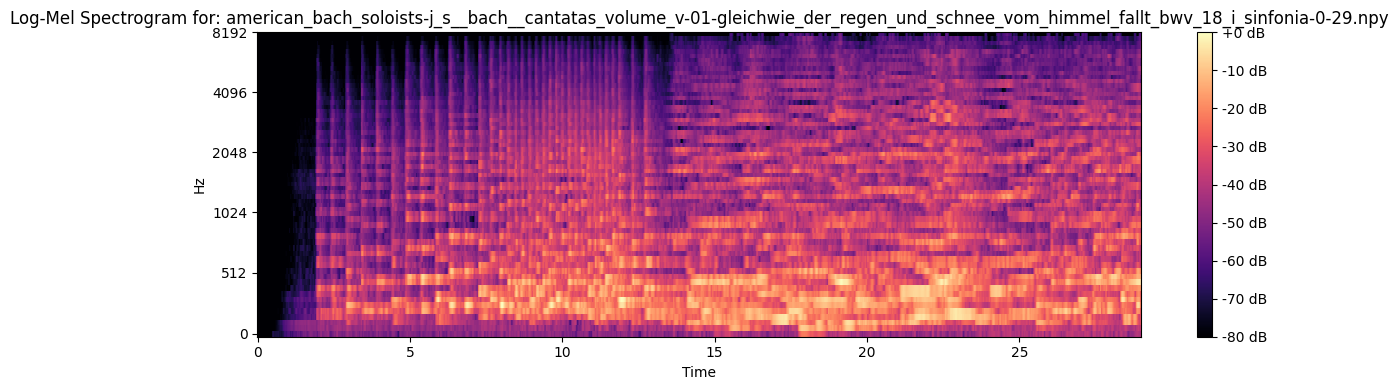

In [ ]:
# Replace with the actual path to one of your generated files
example_path = '/content/spectrograms/0/american_bach_soloists-j_s__bach__cantatas_volume_v-01-gleichwie_der_regen_und_schnee_vom_himmel_fallt_bwv_18_i_sinfonia-0-29.npy'

visualize_spectrogram_npy(example_path)

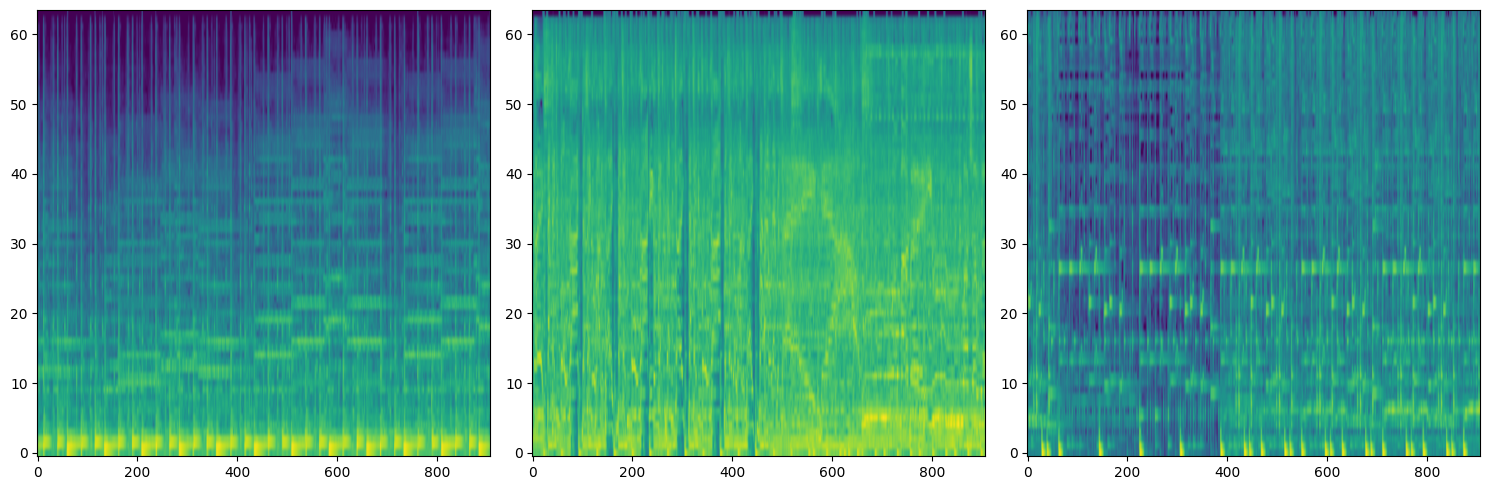

In [ ]:
# Fetch a batch of data
batch = next(iter(train_loader))

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(batch[0].squeeze(1)[i], aspect="auto", origin="lower")
plt.tight_layout()
plt.show()

## Extra Preprocessing

### Generating Spectrograms

In [ ]:
# --- CONFIGURATION CONSTANTS ---
# Ensure these match the settings in your MagnaTagATuneDataset __init__
SAMPLE_RATE = 16000
N_MELS = 64  # Using 64 Mel bands based on your model's requirement
DURATION = 29.0
BASE_AUDIO_DIR = '/content/dataset'  # Folder containing subfolders 0-f with MP3s
OUTPUT_NPY_DIR = '/content/spectrograms/' # New folder where NPY files will be saved

def save_features(clip_id, base_audio_dir, output_npy_dir, sr, n_mels, duration):
    """
    Loads an MP3, generates the log-Mel-spectrogram, and saves it as a .npy file,
    replicating the 16-folder structure based on the clip_id prefix.
    """
    # 1. Determine the subfolder (first character of the clip_id)
    # e.g., '0' for '0001_1.mp3'
    subfolder = clip_id[0]

    # 2. Construct file paths
    audio_path = os.path.join(base_audio_dir, clip_id)

    # Create the output subfolder if it doesn't exist (e.g., 'processed_features_npy/0')
    output_sub_dir = os.path.join(output_npy_dir, subfolder)
    os.makedirs(output_sub_dir, exist_ok=True)

    # 3. Construct the final NPY file path
    feature_filename = clip_id.replace('.mp3', '.npy')
    output_path = os.path.join(output_npy_dir, feature_filename)

    # 4. Processing and Saving
    try:
        # Load audio (y)
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Generate log-Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Save the NumPy array
        np.save(output_path, log_mel)
        return True
    except FileNotFoundError:
        # Crucial for handling missing/corrupted files
        print(f"Error: MP3 file not found at {audio_path}")
        return False
    except Exception as e:
        print(f"Error processing {clip_id}: {e}")
        return False

# --- MAIN PROCESSING LOOP ---
if __name__ == '__main__':
    # Load all unique clip IDs from your full annotations file
    all_clip_ids = df_top50['mp3_path'].unique().tolist()

    # Create the base output folder
    os.makedirs(OUTPUT_NPY_DIR, exist_ok=True)

    total_clips = len(all_clip_ids)
    clips_processed = 0

    print(f"Starting feature generation for {total_clips} clips...")

    for i, clip_id in enumerate(all_clip_ids):
        success = save_features(
            clip_id,
            BASE_AUDIO_DIR,
            OUTPUT_NPY_DIR,
            SAMPLE_RATE,
            N_MELS,
            DURATION
        )
        if success:
            clips_processed += 1

        # Provide status updates
        if (i + 1) % 500 == 0:
            print(f"-> Processed {i + 1}/{total_clips} clips...")

    print("-" * 40)
    print(f"Feature generation complete! Saved {clips_processed} of {total_clips} spectrograms.")
    print(f"Target folder structure created at: {OUTPUT_NPY_DIR}")

Starting feature generation for 25863 clips...
-> Processed 500/25863 clips...
-> Processed 1000/25863 clips...
-> Processed 1500/25863 clips...
-> Processed 2000/25863 clips...
-> Processed 2500/25863 clips...
-> Processed 3000/25863 clips...
-> Processed 3500/25863 clips...
-> Processed 4000/25863 clips...
-> Processed 4500/25863 clips...
-> Processed 5000/25863 clips...
-> Processed 5500/25863 clips...
-> Processed 6000/25863 clips...
-> Processed 6500/25863 clips...
-> Processed 7000/25863 clips...
-> Processed 7500/25863 clips...
-> Processed 8000/25863 clips...
-> Processed 8500/25863 clips...
-> Processed 9000/25863 clips...
-> Processed 9500/25863 clips...
-> Processed 10000/25863 clips...
-> Processed 10500/25863 clips...
-> Processed 11000/25863 clips...
-> Processed 11500/25863 clips...
-> Processed 12000/25863 clips...
-> Processed 12500/25863 clips...
-> Processed 13000/25863 clips...
-> Processed 13500/25863 clips...
-> Processed 14000/25863 clips...
-> Processed 14500/25

/tmp/ipython-input-1400612915.py:37: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=sr, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error processing 6/norine_braun-now_and_zen-08-gently-117-146.mp3: 
-> Processed 16500/25863 clips...
-> Processed 17000/25863 clips...
-> Processed 17500/25863 clips...
-> Processed 18000/25863 clips...
-> Processed 18500/25863 clips...
-> Processed 19000/25863 clips...
-> Processed 19500/25863 clips...
-> Processed 20000/25863 clips...
-> Processed 20500/25863 clips...
-> Processed 21000/25863 clips...
-> Processed 21500/25863 clips...
-> Processed 22000/25863 clips...
-> Processed 22500/25863 clips...
-> Processed 23000/25863 clips...
-> Processed 23500/25863 clips...
-> Processed 24000/25863 clips...
-> Processed 24500/25863 clips...
Error processing 8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3: 
-> Processed 25000/25863 clips...
-> Processed 25500/25863 clips...
Error processing 9/american_baroque-dances_and_suites_of_rameau_and_couperin-25-le_petit_rien_xiveme_ordre_couperin-88-117.mp3: 
----------------------------------------
Feature ge

## Models

### Auxiliar Functions

In [17]:
def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               roc_metric,
               pr_metric):
    """
    Trains the model for a single epoch and returns Loss, ROC-AUC, and PR-AUC.
    """
    # Put model in train mode
    model.train()

    # Ensure metrics are on the correct device
    roc_metric.to(device)
    pr_metric.to(device)

    train_loss = 0

    # Loop through data loader batches
    for X, y in dataloader:
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass (Output: Logits)
        y_pred_logits = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred_logits, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # 6. Update Metrics
        # Pass raw logits and integer targets
        roc_metric.update(y_pred_logits, y.long())
        pr_metric.update(y_pred_logits, y.long())

    # Calculate average loss per batch
    train_loss = train_loss / len(dataloader)

    # 7. Compute final metrics for the epoch and reset internal state
    train_roc_auc = roc_metric.compute().item()
    train_pr_auc = pr_metric.compute().item()

    roc_metric.reset()
    pr_metric.reset()

    return train_loss, train_roc_auc, train_pr_auc

In [18]:
def test_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: nn.Module,
              device: torch.device,
              roc_metric,
              pr_metric):
    """
    Evaluates the model on a test/validation set and returns Loss, ROC-AUC, and PR-AUC.
    """
    # Put model in eval mode
    model.eval()
    roc_metric.to(device)
    pr_metric.to(device)

    test_loss = 0

    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # 3. Update Metrics
            roc_metric.update(test_pred_logits, y.long())
            pr_metric.update(test_pred_logits, y.long())

    # Calculate average loss
    test_loss = test_loss / len(dataloader)

    # 4. Compute final metrics and reset
    test_roc_auc = roc_metric.compute().item()
    test_pr_auc = pr_metric.compute().item()

    roc_metric.reset()
    pr_metric.reset()

    return test_loss, test_roc_auc, test_pr_auc

In [19]:
def train(model: nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer,
          loss_fn: nn.Module,
          epochs: int,
          device: torch.device,
          num_classes: int):
    """
    Main training loop. Initializes metrics once and runs epochs.
    """

    print(f"Initializing training for {num_classes} output classes...")

    # --- INITIALIZE METRICS ---
    # ROC AUC (Macro average)
    roc_metric = torchmetrics.classification.MultilabelAUROC(
        num_labels=num_classes,
        average="macro",
        thresholds=None
    )

    # PR AUC (Macro average) - Requirement for the assignment
    pr_metric = torchmetrics.classification.MultilabelAveragePrecision(
        num_labels=num_classes,
        average="macro",
        thresholds=None
    )

    # Dictionary to store results
    results = {
        "train_loss": [], "train_roc_auc": [], "train_pr_auc": [],
        "test_loss": [], "test_roc_auc": [], "test_pr_auc": []
    }

    # Loop through epochs
    for epoch in tqdm(range(epochs)):

        # 1. Train Step
        train_loss, train_roc, train_pr = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
            roc_metric=roc_metric,
            pr_metric=pr_metric
        )

        # 2. Test Step
        test_loss, test_roc, test_pr = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device,
            roc_metric=roc_metric,
            pr_metric=pr_metric
        )

        # Print results for the current epoch
        print(
          f"Epoch: {epoch+1} | "
          f"Loss: {train_loss:.4f} | "
          f"Train ROC: {train_roc:.4f} | Train PR: {train_pr:.4f} | "
          f"Val ROC: {test_roc:.4f} | Val PR: {test_pr:.4f}"
        )

        # Store results
        results["train_loss"].append(train_loss)
        results["train_roc_auc"].append(train_roc)
        results["train_pr_auc"].append(train_pr)
        results["test_loss"].append(test_loss)
        results["test_roc_auc"].append(test_roc)
        results["test_pr_auc"].append(test_pr)

    return results

### Models

In [22]:
class Transformer(nn.Module):
    """Transformer model for audio classification.

    Args:
        kernel (tuple, optional): Kernel size for the convolutional patch embedding. Defaults to (8, 8).
        stride (tuple, optional): Stride for the convolutional patch embedding. Defaults to (8, 8).
        n_blocks (int, optional): Number of Transformer encoder blocks. Defaults to 2.
        emb_dim (int, optional): Embedding dimension. Defaults to 128.
        n_heads (int, optional): Number of attention heads. Defaults to 2.
        mlp_ratio (int, optional): Ratio of MLP hidden dimension to embedding dimension. Defaults to 2.
        output_size (int, optional): Number of output classes. Defaults to 10.
    """

    def __init__(
        self,
        kernel: tuple = (8, 8),
        stride: tuple = (8, 8),
        n_blocks: int = 2,
        emb_dim: int = 128,
        n_heads: int = 2,
        mlp_ratio: int = 2,
        output_size: int = 10,
        pos_enc_gain: float = 0.0,
        cls_token_ratio: float = 0.0,
    ):
        super().__init__()

        self.n_blocks = n_blocks
        self.emb_dim = emb_dim
        self.n_heads = n_heads
        self.mlp_ratio = mlp_ratio
        self.output_size = output_size
        self.pos_enc_gain = pos_enc_gain
        self.cls_token_ratio = cls_token_ratio

        self.norm = nn.BatchNorm2d(1)

        padding = kernel[0] // 2
        self.patching = nn.Conv2d(
            1, self.emb_dim, kernel_size=kernel, stride=stride, padding=padding
        )

        self.blocks = nn.ModuleList([
          nn.TransformerEncoderLayer(
              self.emb_dim,
              self.n_heads,
              dim_feedforward=self.emb_dim * self.mlp_ratio,
              dropout=0.1,
              norm_first=True,
          ) for _ in range(self.n_blocks)])

        self.cls = nn.Parameter(torch.randn(1, 1, self.emb_dim))

        nn.init.normal_(self.cls, std=0.02)

        self.fc1 = nn.Linear(self.emb_dim, self.emb_dim)
        self.fc2 = nn.Linear(self.emb_dim, self.output_size)

    def positional_encoding(self, seq_len):
        position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, self.emb_dim, 2, dtype=torch.float32) * -(math.log(10000.0) / self.emb_dim))

        pe = torch.zeros(seq_len, self.emb_dim, device=self.cls.device)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, x):
        # Add embedding dimension
        #x = x.unsqueeze(1)

        # Normalize input to zero-mean unit std.
        x = self.norm(x)

        # Divide the signal into patches
        x = self.patching(x)  # [B, 1, freq, time] -> [b, E, M, T]

        B, E, M, T = x.shape

        # Generate positional encodings for frequency and time
        pe_m = self.positional_encoding(M) # (M, E)
        pe_t = self.positional_encoding(T) # (T, E)

        pe_m_reshaped = pe_m.transpose(0, 1).unsqueeze(0).unsqueeze(3) # (1, E, F, 1)
        pe_t_reshaped = pe_t.transpose(0, 1).unsqueeze(0).unsqueeze(2) # (1, E, 1, T)

        # Add positional encoding with small gain.
        x = x + self.pos_enc_gain * (pe_m_reshaped + pe_t_reshaped)

        x = x.flatten(start_dim=2)  # [B, E, F, T] -> [B, E, F * T]
        x = x.swapaxes(1, 2)  # [B, E, F * T] -> [B, F * T, E]

        # Concatenate CLS token
        cls = self.cls.repeat(B, 1, 1)
        x = torch.cat([cls, x], dim=1)

        # Transformer backbone
        for block in self.blocks:
          x = block(x)

        # Classification on top of the CLS + average of the rest of tokens
        x_cls = x[:, 0, :]
        x_mean = x[:, 1:, :].mean(dim=1)
        x = self.cls_token_ratio * x_cls + (1 - self.cls_token_ratio) * x_mean

        # Dense classification head
        x = F.layer_norm(x, (self.emb_dim,))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### Train

In [23]:
# --- CONFIGURATION AND EXECUTION ---

# 1. Define Device
print(f"Using device: {device}")

# 2. Define Number of Classes
# This must match the number of columns in your label dataframe (e.g., 50)
num_classes = len(train_dataset.label_columns)

Using device: cuda


#### Transformer Basic (no Positional Encoding)

In [37]:
# 3. Instantiate the Transformer Model
transformer_basic = Transformer(
    n_blocks=2,
    emb_dim=64,
    n_heads=4,
    output_size=num_classes
)

# Move model to GPU/CPU
transformer_basic.to(device)

num_params = sum(p.numel() for p in transformer_basic.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 78580


In [38]:
# 4. Define Loss Function and Optimizer
# NOTE: We use BCEWithLogitsLoss because this is a Multi-Label problem (Tags are not mutually exclusive)
loss_fn = nn.BCEWithLogitsLoss()

# Adam optimizer with a standard learning rate for Transformers
optimizer = torch.optim.Adam(transformer_basic.parameters(), lr=1e-4)

In [39]:
%%time

# 5. Run Training
print("\nStarting Transformer training on MagnaTagATune...")
transformer_basic_results = train(
    model=transformer_basic,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,             # Adjust epochs as needed
    device=device,
    num_classes=num_classes
)


Starting Transformer training on MagnaTagATune...
Initializing training for 50 output classes...


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | Loss: 0.2851 | Train ROC: 0.5107 | Train PR: 0.0561 | Val ROC: 0.5776 | Val PR: 0.0955
Epoch: 2 | Loss: 0.1928 | Train ROC: 0.5950 | Train PR: 0.0896 | Val ROC: 0.6385 | Val PR: 0.1153
Epoch: 3 | Loss: 0.1828 | Train ROC: 0.6636 | Train PR: 0.1161 | Val ROC: 0.6776 | Val PR: 0.1349
Epoch: 4 | Loss: 0.1770 | Train ROC: 0.6954 | Train PR: 0.1351 | Val ROC: 0.6881 | Val PR: 0.1403
Epoch: 5 | Loss: 0.1741 | Train ROC: 0.7163 | Train PR: 0.1479 | Val ROC: 0.6959 | Val PR: 0.1468
Epoch: 6 | Loss: 0.1711 | Train ROC: 0.7374 | Train PR: 0.1621 | Val ROC: 0.7130 | Val PR: 0.1521
Epoch: 7 | Loss: 0.1678 | Train ROC: 0.7598 | Train PR: 0.1793 | Val ROC: 0.7255 | Val PR: 0.1612
Epoch: 8 | Loss: 0.1640 | Train ROC: 0.7813 | Train PR: 0.1973 | Val ROC: 0.7510 | Val PR: 0.1833
Epoch: 9 | Loss: 0.1607 | Train ROC: 0.7951 | Train PR: 0.2122 | Val ROC: 0.7615 | Val PR: 0.1944
Epoch: 10 | Loss: 0.1581 | Train ROC: 0.8059 | Train PR: 0.2235 | Val ROC: 0.7758 | Val PR: 0.2046
Epoch: 11 | Loss: 0

#### Transformer with some Positional Encoding

In [24]:
# 3. Instantiate the Transformer Model
transformer = Transformer(
    n_blocks=2,           # Number of encoder blocks
    emb_dim=128,          # Embedding dimension
    n_heads=4,            # Attention heads
    mlp_ratio=2,
    output_size=num_classes, # Output neurons = Number of tags
    pos_enc_gain=0.1      # <--- CRITICAL: Must be > 0.0 for the Transformer to learn position
)

# Move model to GPU/CPU
transformer.to(device)

num_params = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

Number of trainable parameters: 296372


In [29]:
batch = next(iter(test_loader))
dummy_data = batch[0][0].unsqueeze(0).to(device)
print(dummy_data.shape)

transformer(dummy_data)

torch.Size([1, 1, 64, 907])


tensor([[ 0.1759, -0.2024, -0.5231,  0.1657, -0.0067, -0.1283,  0.1872,  0.0751,
         -0.0740, -0.0436, -0.1073, -0.1668,  0.3993,  0.4387,  0.4376,  0.0270,
         -0.0622, -0.0057,  0.1286, -0.0959, -0.3174,  0.0947,  0.1415,  0.2215,
          0.1703,  0.2087, -0.0218, -0.0801, -0.3526, -0.0514, -0.1730, -0.0713,
         -0.0312,  0.1023, -0.3007,  0.0632, -0.1703,  0.2314,  0.4098, -0.0952,
          0.1200, -0.0901, -0.2932, -0.3352, -0.4409,  0.0489, -0.3704,  0.0106,
         -0.2282, -0.3578]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [30]:
# 4. Define Loss Function and Optimizer
# NOTE: We use BCEWithLogitsLoss because this is a Multi-Label problem (Tags are not mutually exclusive)
loss_fn = nn.BCEWithLogitsLoss()

# Adam optimizer with a standard learning rate for Transformers
optimizer = torch.optim.Adam(transformer.parameters(), lr=1e-4)

In [31]:
%%time

# 5. Run Training
print("\nStarting Transformer training on MagnaTagATune...")
transformer_results = train(
    model=transformer,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,             # Adjust epochs as needed
    device=device,
    num_classes=num_classes
)


Starting Transformer training on MagnaTagATune...
Initializing training for 50 output classes...


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | Loss: 0.2364 | Train ROC: 0.5468 | Train PR: 0.0615 | Val ROC: 0.6163 | Val PR: 0.1025
Epoch: 2 | Loss: 0.1830 | Train ROC: 0.6635 | Train PR: 0.1163 | Val ROC: 0.6840 | Val PR: 0.1409
Epoch: 3 | Loss: 0.1739 | Train ROC: 0.7126 | Train PR: 0.1481 | Val ROC: 0.7076 | Val PR: 0.1535
Epoch: 4 | Loss: 0.1680 | Train ROC: 0.7498 | Train PR: 0.1758 | Val ROC: 0.7349 | Val PR: 0.1782
Epoch: 5 | Loss: 0.1622 | Train ROC: 0.7791 | Train PR: 0.2055 | Val ROC: 0.7620 | Val PR: 0.1999
Epoch: 6 | Loss: 0.1575 | Train ROC: 0.8030 | Train PR: 0.2281 | Val ROC: 0.7869 | Val PR: 0.2248
Epoch: 7 | Loss: 0.1543 | Train ROC: 0.8185 | Train PR: 0.2412 | Val ROC: 0.8076 | Val PR: 0.2386
Epoch: 8 | Loss: 0.1515 | Train ROC: 0.8291 | Train PR: 0.2569 | Val ROC: 0.8152 | Val PR: 0.2442
Epoch: 9 | Loss: 0.1492 | Train ROC: 0.8376 | Train PR: 0.2665 | Val ROC: 0.8215 | Val PR: 0.2530
Epoch: 10 | Loss: 0.1473 | Train ROC: 0.8442 | Train PR: 0.2770 | Val ROC: 0.8286 | Val PR: 0.2577
Epoch: 11 | Loss: 0

#### Transformer Final

In [35]:
transformer_best = Transformer(
    # --- Patching Structure ---
    # Larger patches create a more manageable sequence length
    # and help capture local spectral-temporal structures.
    kernel=(16, 16),
    stride=(16, 16),

    # --- Model Capacity ---
    n_blocks=4,           # 2 is too shallow; 4 is a standard "Small" architecture.
    emb_dim=256,          # 128 is a bit narrow for complex audio; 256 is the sweet spot.
    n_heads=8,            # Must divide emb_dim (256/8 = 32 dim per head).
    mlp_ratio=4,          # Standard ratio in Vision Transformer papers.

    # --- Critical Training Flags ---
    output_size=num_classes,
    pos_enc_gain=1.0,     # CRITICAL: If 0.0, the model is "position-blind."
    cls_token_ratio=0.5   # Balanced mix of CLS info and Global Average Pooling.
)

# Move model to GPU/CPU
transformer_best.to(device)

num_params = sum(p.numel() for p in transformer_best.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")

# --- Optimizer and Loss ---
# Transformers require weight decay to prevent overfitting.
# AdamW is the industry standard for Transformers.
optimizer = torch.optim.AdamW(transformer_best.parameters(), lr=3e-4, weight_decay=1e-4)

# Loss for Multi-label classification
loss_fn = nn.BCEWithLogitsLoss()

Number of trainable parameters: 3303732


In [36]:
%%time

# 5. Run Training
print("\nStarting Transformer training on MagnaTagATune...")
transformer_best_results = train(
    model=transformer_best,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=15,             # Adjust epochs as needed
    device=device,
    num_classes=num_classes
)


Starting Transformer training on MagnaTagATune...
Initializing training for 50 output classes...


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | Loss: 0.1971 | Train ROC: 0.6207 | Train PR: 0.0838 | Val ROC: 0.7139 | Val PR: 0.1458
Epoch: 2 | Loss: 0.1743 | Train ROC: 0.7259 | Train PR: 0.1438 | Val ROC: 0.7616 | Val PR: 0.1701
Epoch: 3 | Loss: 0.1699 | Train ROC: 0.7563 | Train PR: 0.1632 | Val ROC: 0.7742 | Val PR: 0.1897
Epoch: 4 | Loss: 0.1646 | Train ROC: 0.7824 | Train PR: 0.1921 | Val ROC: 0.7869 | Val PR: 0.2151
Epoch: 5 | Loss: 0.1591 | Train ROC: 0.8062 | Train PR: 0.2220 | Val ROC: 0.7964 | Val PR: 0.2254
Epoch: 6 | Loss: 0.1564 | Train ROC: 0.8170 | Train PR: 0.2353 | Val ROC: 0.8052 | Val PR: 0.2483
Epoch: 7 | Loss: 0.1535 | Train ROC: 0.8270 | Train PR: 0.2518 | Val ROC: 0.8111 | Val PR: 0.2459
Epoch: 8 | Loss: 0.1515 | Train ROC: 0.8339 | Train PR: 0.2633 | Val ROC: 0.8221 | Val PR: 0.2626
Epoch: 9 | Loss: 0.1495 | Train ROC: 0.8406 | Train PR: 0.2726 | Val ROC: 0.8204 | Val PR: 0.2587
Epoch: 10 | Loss: 0.1480 | Train ROC: 0.8459 | Train PR: 0.2787 | Val ROC: 0.8217 | Val PR: 0.2580
Epoch: 11 | Loss: 0

## Results

This experiment explored the efficacy of Vision Transformer (ViT) architectures adapted for audio spectrogram classification on the MagnaTagATune dataset. Three distinct model configurations were trained to evaluate the impact of positional encoding, model capacity, and patch resolution. The results demonstrate that while Transformers can effectively learn spectral features, their performance is heavily dependent on spatial awareness (positional encoding) and an appropriate balance of model complexity.
Methodology and Design Decisions

The study progressed through three incremental model configurations:

1. Baseline (Basic Transformer): A lightweight model (78k parameters, 2 blocks) initialized without positional encoding. This served as a control to test if the self-attention mechanism alone could act as a "bag-of-features" extractor, treating the spectrogram as an unordered set of patches.

2. Context-Aware (Positional Encoding): A mid-sized model (296k parameters) incorporating a positional encoding gain of 0.1. This decision aimed to validate the hypothesis that temporal order (rhythm) and frequency order (pitch height) are critical for music classification.

3. High-Capacity (Optimized): A larger architecture (3.3M parameters, 4 blocks, 256 embedding dim) with (16,16) patching and decoupled weight decay (AdamW). This configuration was designed to maximize feature extraction capability and test the limits of the dataset before overfitting occurred.

### Results and Observations

* The Critical Role of Positional Encoding: The most significant performance leap occurred between the Basic model and the Context-Aware model. The Basic model, effectively "blind" to the structure of time and frequency, struggled to break the 0.60 ROC-AUC barrier in early epochs, requiring 15 epochs to reach a validation ROC of 0.80. In contrast, simply adding positional awareness allowed the second model to surpass that same threshold by Epoch 7. This confirms that music classification relies heavily on structural relationships (e.g., distinguishing a low-frequency kick drum from a high-frequency hi-hat) rather than just the presence of raw textures.

* Model Capacity vs. Efficiency The High-Capacity: "Best" model demonstrated superior learning dynamics in the early stages. By Epoch 1, it had already achieved a validation ROC of 0.71, a score the Basic model did not reach until Epoch 6. However, as training progressed, the performance gap between the mid-sized Context-Aware model (296k params) and the High-Capacity model (3.3M params) narrowed.

    Context-Aware (Epoch 15): Val ROC: 0.841 | Val PR-AUC: 0.272

    High-Capacity (Epoch 15): Val ROC: 0.838 | Val PR-AUC: 0.279

* Analysis of Convergence and Overfitting:  While the High-Capacity model achieved the highest peak Precision-Recall (PR) score (0.284 at Epoch 12), it showed signs of diminishing returns after Epoch 10. The validation metrics stabilized while training metrics continued to improve, suggesting the onset of mild overfitting typical of larger Transformers on medium-sized datasets. Interestingly, the Context-Aware model (approx. 10x smaller) remained highly competitive, achieving a slightly higher final ROC-AUC (0.841 vs 0.838).
Conclusion

The experiments confirm that a Transformer encoder is a viable architecture for multi-label audio classification, provided that Positional Encoding is enabled. While increasing model size accelerates convergence and marginally improves precision (PR-AUC), the mid-sized architecture offered the best trade-off between computational efficiency and predictive performance. For deployment or further tuning, the 296k parameter model with positional encoding represents the most efficient solution, while the larger model would benefit from stronger regularization (e.g., higher dropout or data augmentation) to fully utilize its capacity.